In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import shap
from sklearn.cluster import AgglomerativeClustering


In [25]:
# Load dataset with clusters
df = pd.read_json("../data/supervise_myth_clusters.json", lines=True)

df['myth_theme'].value_counts()
#df.columns

myth_theme
Shapeshifters, Rebirth & Primal Archetypes    794
Divine Conflict & Deific Representation       609
Rebirth, Prophecy & Fate                      528
Morally Grey: the Antihero’s Path             344
Name: count, dtype: int64

In [7]:
#start supervised learning techniques - predicting cluster membership
# Define input features and target label
features = [
    "has_lexical_match",
    "has_semantic_match",
    "has_sentence_myth_trope_hit",
    "myth_hit_count",
    "max_trope_similarity",
    "inferred_media_type",
    "imdb_year"
]

X = df[features]
y = df["myth_theme"]

In [ ]:
categorical = ["inferred_media_type"]
numerical = ["myth_hit_count", "max_trope_similarity", "imdb_year"]
boolean = ["has_lexical_match", "has_semantic_match", "has_sentence_myth_trope_hit"]


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])


categorical_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numerical),
    ("cat", categorical_pipe, categorical),
    ("bool", "passthrough", boolean)
])

In [9]:
models = {
    "Logistic Regression": LogisticRegression(multi_class="multinomial", max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [10]:
results = {}

for name, model in models.items():
    pipe = make_pipeline(preprocessor, model)
    scores = cross_val_score(pipe, X, y, cv=5, scoring="f1_macro")
    results[name] = (scores.mean(), scores.std())
    print(f"{name}: F1 = {scores.mean():.3f} ± {scores.std():.3f}")

c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1264: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\Eric\.vscode\milestone-mythology\.mythenv\Lib\sit

Logistic Regression: F1 = 0.490 ± 0.019
Random Forest: F1 = 0.634 ± 0.051
KNN: F1 = 0.562 ± 0.020


In [ ]:
#dropping KNN and Logistic Regression due to low performance
#rebuilding pipeline with Random Forest
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=100, random_state=42))
])


rf_pipeline.fit(X, y)


feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()


importances = rf_pipeline.named_steps["clf"].feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(10)

,feature,importance
1,num__max_trope_similarity,0.369141
7,cat__inferred_media_type_unknown,0.269017
2,num__imdb_year,0.229821
5,cat__inferred_media_type_screen,0.051326
4,cat__inferred_media_type_both,0.027743
3,cat__inferred_media_type_book,0.023088
6,cat__inferred_media_type_skip,0.013607
0,num__myth_hit_count,0.011405
8,bool__has_lexical_match,0.003151
9,bool__has_semantic_match,0.001042


C:\Users\Eric\AppData\Local\Temp\ipykernel_21032\914376347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp.head(10), x="importance", y="feature", palette="viridis")


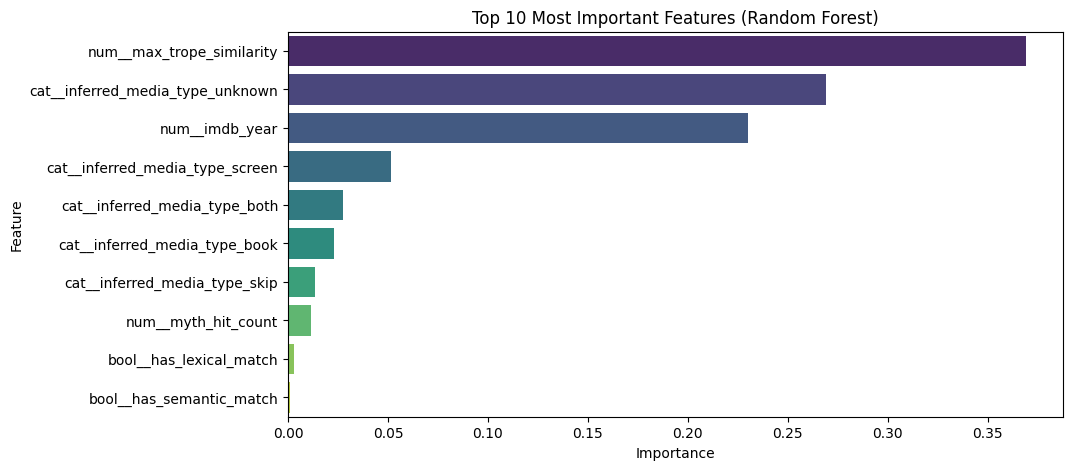

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=feat_imp.head(10), x="importance", y="feature", palette="viridis")
plt.title("Top 10 Most Important Features (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:

reduced_features = [
    "max_trope_similarity",
    "inferred_media_type",
    "imdb_year"
]

X_reduced = df[reduced_features]
y = df["myth_theme"]


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

reduced_preprocessor = ColumnTransformer([
    ("num", numeric_pipe, ["max_trope_similarity", "imdb_year"]),
    ("cat", categorical_pipe, ["inferred_media_type"])
])


reduced_pipeline = make_pipeline(
    reduced_preprocessor,
    RandomForestClassifier(n_estimators=100, random_state=42)
)

scores = cross_val_score(reduced_pipeline, X_reduced, y, cv=5, scoring="f1_macro")
print(f"Reduced model F1 (macro): {scores.mean():.3f} ± {scores.std():.3f}")

Reduced model F1 (macro): 0.625 ± 0.049


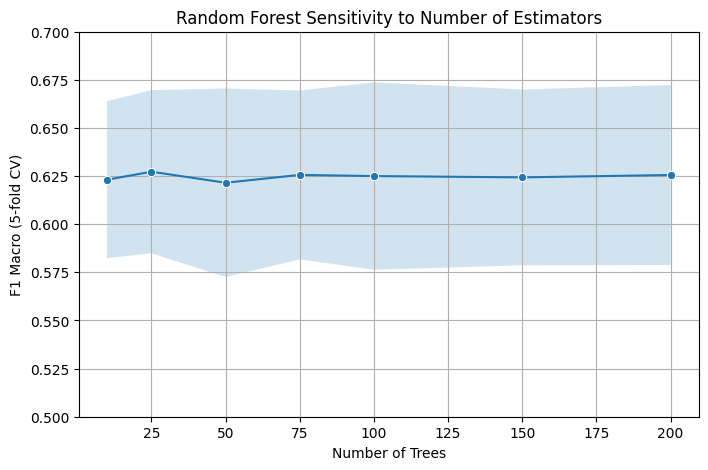

In [ ]:
#model is making almost all decisions based on max_trope_similarity, media type, and year

#hyperparameter tuning
n_estimators_range = [10, 25, 50, 75, 100, 150, 200]
results = []

for n in n_estimators_range:
    pipeline = make_pipeline(
        reduced_preprocessor,
        RandomForestClassifier(n_estimators=n, random_state=42)
    )
    scores = cross_val_score(pipeline, X_reduced, y, cv=5, scoring="f1_macro")
    results.append({
        "n_estimators": n,
        "mean_f1": scores.mean(),
        "std_f1": scores.std()
    })


sensitivity_df = pd.DataFrame(results)


plt.figure(figsize=(8, 5))
sns.lineplot(data=sensitivity_df, x="n_estimators", y="mean_f1", marker="o")
plt.fill_between(
    sensitivity_df["n_estimators"],
    sensitivity_df["mean_f1"] - sensitivity_df["std_f1"],
    sensitivity_df["mean_f1"] + sensitivity_df["std_f1"],
    alpha=0.2
)
plt.title("Random Forest Sensitivity to Number of Estimators")
plt.xlabel("Number of Trees")
plt.ylabel("F1 Macro (5-fold CV)")
plt.ylim(0.5, 0.7)
plt.grid(True)
plt.show()

In [ ]:
#failure analysis
# Reuse the best model (Random Forest + reduced features)
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced, y, test_size=0.2, stratify=y, random_state=42
)


reduced_pipeline.fit(X_train, y_train)


y_pred = reduced_pipeline.predict(X_test)


df_test = X_test.copy()
df_test["actual"] = y_test.values
df_test["predicted"] = y_pred
df_test["correct"] = df_test["actual"] == df_test["predicted"]

# Filter for misclassified examples
failures = df_test[df_test["correct"] == False]
failures.head()

,max_trope_similarity,inferred_media_type,imdb_year,actual,predicted,correct
1256,0.063054,both,1948.0,"Rebirth, Prophecy & Fate",Divine Conflict & Deific Representation,False
1332,0.000000,screen,2017.0,"Shapeshifters, Rebirth & Primal Archetypes","Rebirth, Prophecy & Fate",False
1194,0.036779,both,2019.0,Morally Grey: the Antihero’s Path,"Rebirth, Prophecy & Fate",False
1259,0.071534,screen,2013.0,Morally Grey: the Antihero’s Path,"Rebirth, Prophecy & Fate",False
1504,0.092921,both,2008.0,"Rebirth, Prophecy & Fate",Divine Conflict & Deific Representation,False


In [16]:
failures = failures.merge(df[["id", "combined_text", "type", "inferred_media_type", "myth_theme"]], 
                          left_index=True, right_index=True, how="left")

failures.head()

,max_trope_similarity,inferred_media_type_x,imdb_year,actual,predicted,correct,id,combined_text,type,inferred_media_type_y,myth_theme
1256,0.063054,both,1948.0,"Rebirth, Prophecy & Fate",Divine Conflict & Deific Representation,False,media_onetouchofvenus(film),One Touch of Venus One Touch of Venus In the a...,modern_media,both,"Rebirth, Prophecy & Fate"
1332,0.000000,screen,2017.0,"Shapeshifters, Rebirth & Primal Archetypes","Rebirth, Prophecy & Fate",False,media_marvelcinematicuniverse,The Marvel Cinematic Universe Analyzed,modern_media,screen,"Shapeshifters, Rebirth & Primal Archetypes"
1194,0.036779,both,2019.0,Morally Grey: the Antihero’s Path,"Rebirth, Prophecy & Fate",False,media_whatwedointheshadows(tvseries),HPI: What We Do in the Shadows In this excitin...,modern_media,both,Morally Grey: the Antihero’s Path
1259,0.071534,screen,2013.0,Morally Grey: the Antihero’s Path,"Rebirth, Prophecy & Fate",False,media_percyjackson:seaofmonsters,Percy Jackson: Sea of Monsters Percy Jackson r...,modern_media,screen,Morally Grey: the Antihero’s Path
1504,0.092921,both,2008.0,"Rebirth, Prophecy & Fate",Divine Conflict & Deific Representation,False,media_worldofquest,"The World of Quest In the land of Odyssia, for...",modern_media,both,"Rebirth, Prophecy & Fate"


In [ ]:
#SHAP analysis - random forest model

reduced_pipeline = make_pipeline(
    reduced_preprocessor,
    RandomForestClassifier(n_estimators=100, random_state=42)
)
reduced_pipeline.fit(X_reduced, y)  


rf_model = reduced_pipeline.named_steps['randomforestclassifier']
preprocessor = reduced_pipeline.named_steps['columntransformer']


X_transformed = preprocessor.transform(X_reduced)


explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_transformed)

fail_ids = [
    "media_whatwedointheshadows(tvseries)",
    "media_percyjackson:seaofmonsters",
    "media_worldofquest"
]

fail_rows = df[df["id"].isin(fail_ids)]
X_fail = X_reduced.loc[fail_rows.index]  s


X_fail_transformed = preprocessor.transform(X_fail)

In [ ]:


print(len(shap_values_fail))  
print(shap_values_fail[0].shape)  

3
(7, 4)


In [ ]:

shap.initjs()


X_fail_transformed = preprocessor.transform(X_fail)
shap_values_fail = explainer.shap_values(X_fail_transformed)


X_fail_dense = X_fail_transformed.toarray() if hasattr(X_fail_transformed, "toarray") else X_fail_transformed


feature_names = preprocessor.get_feature_names_out()


for i in range(len(X_fail)):

    predicted_class = model.predict(X_fail)[i]


    display(shap.force_plot(
        base_value=explainer.expected_value[predicted_class],
        shap_values=shap_values_fail[predicted_class][i],
        features=X_fail_dense[i],
        feature_names=feature_names
    ))

NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:

X_fail_transformed = preprocessor.transform(X_fail)
shap_values_fail = explainer.shap_values(X_fail_transformed)


X_fail_dense = X_fail_transformed.toarray() if hasattr(X_fail_transformed, "toarray") else X_fail_transformed


shap.initjs()
for i in range(len(X_fail)):
    display(shap.force_plot(
        base_value=explainer.expected_value[1],  
        shap_values=shap_values_fail[1][i],       
        features=X_fail_dense[i],                 
        feature_names=preprocessor.get_feature_names_out()
    ))

DimensionError: Length of features is not equal to the length of shap_values!

In [ ]:

features = [
    "max_trope_similarity",
    "imdb_year",
    "inferred_media_type",
    "has_lexical_match",
    "has_semantic_match",
    "has_myth_hit",
    "has_myth_trope_hit",
    "myth_hit_count"
]

X = df[features]
y = df["myth_theme"]  


numerical = [ "imdb_year", "myth_hit_count", "max_trope_similarity"]
categorical = ["inferred_media_type"]
boolean = ["has_lexical_match", "has_semantic_match", "has_myth_hit", "has_myth_trope_hit"]


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


full_preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numerical),
    ("cat", categorical_pipe, categorical),
    ("bool", "passthrough", boolean)
])


pipeline = make_pipeline(
    full_preprocessor,
    RandomForestClassifier(n_estimators=100, random_state=42)
)


scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1_macro")
print(f"F1 macro (myth features included): {scores.mean():.3f} ± {scores.std():.3f}")

F1 macro (myth features included): 0.637 ± 0.052


In [ ]:

features = [
    "max_trope_similarity",
    "imdb_year",
    "inferred_media_type",
    "has_lexical_match",
    "has_semantic_match",
    "has_myth_hit",
    "has_myth_trope_hit",
    "myth_hit_count"
]


X = df[features]
y = df["agglo_cluster"]  


numerical = ["max_trope_similarity", "imdb_year", "myth_hit_count"]
categorical = ["inferred_media_type"]
boolean = ["has_lexical_match", "has_semantic_match", "has_myth_hit", "has_myth_trope_hit"]


numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numerical),
    ("cat", categorical_pipe, categorical),
    ("bool", "passthrough", boolean)
])


models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}


for name, model in models.items():
    pipeline = make_pipeline(preprocessor, model)
    scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1_macro")
    print(f"{name}: F1 = {scores.mean():.3f} ± {scores.std():.3f}")

Logistic Regression: F1 = 0.220 ± 0.012
Random Forest: F1 = 0.430 ± 0.099
KNN: F1 = 0.294 ± 0.024
